# Cross-Basin TC Forecasting: Model Comparison

Side-by-side evaluation of three architectures trained on the **Western Pacific (WP)** basin and evaluated on the **South Pacific (SP)** basin for tropical cyclone direction (8 classes) and intensity-change (4 classes) prediction.

| Model | Key idea | Parameters |
|-------|----------|------------|
| **FNO** | Global convolution in Fourier space (spectral layers) | ~1M |
| **ResNet-18** | Deep residual blocks with skip connections | ~11M |
| **U-Net** | Encoder-decoder with SE attention & skip connections | ~5M |

All models share the same **CycloneDataset**, **data splits**, and **late-fusion** strategy (grid + env + 1D features).

## 1. Setup & Data Loading

In [7]:
import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
from sklearn.metrics import (
    confusion_matrix, classification_report, f1_score, accuracy_score
)
from pathlib import Path
from collections import Counter
import warnings, os

warnings.filterwarnings("ignore")
sns.set_theme(style="whitegrid", font_scale=1.1)

# ── Paths ──
PROJECT_ROOT = Path("..").resolve()
DATA_DIR = PROJECT_ROOT / "data" / "processed"
EXP_DIR  = PROJECT_ROOT / "experiments"
FIG_DIR  = PROJECT_ROOT / "figures"
FIG_DIR.mkdir(exist_ok=True)

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
BATCH_SIZE = 64

N_DIR_CLASSES = 8
N_INT_CLASSES = 4
DIR_LABELS  = ["E", "SE", "S", "SW", "W", "NW", "N", "NE"]
INTE_LABELS = ["Weakening", "Steady", "Slow-intens.", "Rapid-intens."]

print(f"Device: {DEVICE}")

Device: cuda


In [8]:
# ── Dataset (shared across all models) ──
class CycloneDataset(Dataset):
    """Flattens storm-level dicts into timestep-level samples.
    Filters sentinel labels (-1). 1D features z-scored with WP train stats."""
    def __init__(self, grids, env, data1d, labels, use_reflected=False,
                 d1d_mean=None, d1d_std=None):
        self.samples = []
        dir_key = "direction_reflected" if use_reflected else "direction"
        for storm_id in grids:
            g = grids[storm_id]
            e = env[storm_id]
            d = data1d[storm_id]
            d_lbl = labels[storm_id][dir_key]
            i_lbl = labels[storm_id]["intensity"]
            for t in range(g.shape[0]):
                if d_lbl[t].item() == -1 or i_lbl[t].item() == -1:
                    continue
                self.samples.append((
                    g[t], e[t], d[t], d_lbl[t].long(), i_lbl[t].long()))
        if d1d_mean is None:
            all_1d = torch.stack([s[2] for s in self.samples])
            self.d1d_mean = all_1d.mean(dim=0)
            self.d1d_std  = all_1d.std(dim=0).clamp(min=1e-6)
        else:
            self.d1d_mean, self.d1d_std = d1d_mean, d1d_std

    def __len__(self): return len(self.samples)

    def __getitem__(self, idx):
        grid, env, d1d, dir_lbl, int_lbl = self.samples[idx]
        d1d = (d1d - self.d1d_mean) / self.d1d_std
        return grid, env, d1d, dir_lbl, int_lbl


# ── Load splits ──
SPLITS = {
    "wp_train":    {"reflected": False},
    "wp_val":      {"reflected": False},
    "sp_test":     {"reflected": True},
    "sp_ft_train": {"reflected": True},
    "sp_ft_val":   {"reflected": True},
}

raw = {}
for split in SPLITS:
    raw[split] = {
        "grids":  torch.load(DATA_DIR / "grids"  / f"{split}_grids.pt",  weights_only=False),
        "env":    torch.load(DATA_DIR / "env"     / f"{split}_env.pt",    weights_only=False),
        "data1d": torch.load(DATA_DIR / "data1d"  / f"{split}_1d.pt",    weights_only=False),
        "labels": torch.load(DATA_DIR / "labels"  / f"{split}_labels.pt", weights_only=False),
    }

datasets = {}
datasets["wp_train"] = CycloneDataset(
    raw["wp_train"]["grids"], raw["wp_train"]["env"],
    raw["wp_train"]["data1d"], raw["wp_train"]["labels"])
d1d_mean = datasets["wp_train"].d1d_mean
d1d_std  = datasets["wp_train"].d1d_std

for split, cfg in SPLITS.items():
    if split == "wp_train":
        continue
    datasets[split] = CycloneDataset(
        raw[split]["grids"], raw[split]["env"], raw[split]["data1d"],
        raw[split]["labels"], use_reflected=cfg["reflected"],
        d1d_mean=d1d_mean, d1d_std=d1d_std)

loaders = {}
for split in SPLITS:
    loaders[split] = DataLoader(
        datasets[split], batch_size=BATCH_SIZE, shuffle=False,
        num_workers=0, pin_memory=True)

for s, ds in datasets.items():
    print(f"  {s:15s}: {len(ds):5d} samples")

  wp_train       :  3252 samples
  wp_val         :   730 samples
  sp_test        :   367 samples
  sp_ft_train    :   354 samples
  sp_ft_val      :    81 samples


## 2. Model Definitions

Each architecture is defined below with the **exact same structure** used during training, so that saved checkpoints can be loaded directly.

In [9]:
# ═══════════════════════════════════════════════════════════════
# FNO (Fourier Neural Operator)
# ═══════════════════════════════════════════════════════════════

class SpectralConv2d(nn.Module):
    """2D Fourier spectral convolution layer."""
    def __init__(self, in_channels, out_channels, modes1, modes2):
        super().__init__()
        self.in_channels  = in_channels
        self.out_channels = out_channels
        self.modes1 = modes1
        self.modes2 = modes2
        scale = (2 / (in_channels + out_channels)) ** 0.5
        self.weights1 = nn.Parameter(
            scale * (torch.rand(in_channels, out_channels, modes1, modes2,
                                dtype=torch.cfloat) - 0.5))
        self.weights2 = nn.Parameter(
            scale * (torch.rand(in_channels, out_channels, modes1, modes2,
                                dtype=torch.cfloat) - 0.5))

    def compl_mul2d(self, x, weights):
        return torch.einsum("bixy,ioxy->boxy", x, weights)

    def forward(self, x):
        B, _, H, W = x.shape
        x_ft = torch.fft.rfft2(x)
        out_ft = torch.zeros(B, self.out_channels, H, W // 2 + 1,
                             dtype=torch.cfloat, device=x.device)
        out_ft[:, :, :self.modes1, :self.modes2] = \
            self.compl_mul2d(x_ft[:, :, :self.modes1, :self.modes2], self.weights1)
        out_ft[:, :, -self.modes1:, :self.modes2] = \
            self.compl_mul2d(x_ft[:, :, -self.modes1:, :self.modes2], self.weights2)
        return torch.fft.irfft2(out_ft, s=(H, W))


class FNO2dClassifier(nn.Module):
    """FNO with BatchNorm, residual connections, and late fusion."""
    def __init__(self, in_channels=15, hidden_channels=80, n_modes=20,
                 n_layers=2, n_dir_classes=8, n_int_classes=4,
                 env_dim=40, d1d_dim=4, use_env=True, use_1d=True,
                 dropout=0.1):
        super().__init__()
        self.use_env = use_env
        self.use_1d  = use_1d
        self.lifting = nn.Sequential(nn.Conv2d(in_channels, hidden_channels, 1), nn.GELU())
        self.spectral_layers = nn.ModuleList()
        self.skip_convs      = nn.ModuleList()
        self.norms           = nn.ModuleList()
        self.dropouts        = nn.ModuleList()
        for _ in range(n_layers):
            self.spectral_layers.append(SpectralConv2d(hidden_channels, hidden_channels, n_modes, n_modes))
            self.skip_convs.append(nn.Conv2d(hidden_channels, hidden_channels, 1))
            self.norms.append(nn.BatchNorm2d(hidden_channels))
            self.dropouts.append(nn.Dropout2d(dropout))
        self.projection = nn.Sequential(nn.Conv2d(hidden_channels, hidden_channels, 1), nn.GELU())
        aux_dim = (env_dim if use_env else 0) + (d1d_dim if use_1d else 0)
        head_in = hidden_channels + aux_dim
        self.head_dir = nn.Sequential(
            nn.Linear(head_in, 64), nn.GELU(), nn.Dropout(0.2),
            nn.Linear(64, 32), nn.GELU(), nn.Dropout(0.1),
            nn.Linear(32, n_dir_classes))
        self.head_int = nn.Sequential(
            nn.Linear(head_in, 64), nn.GELU(), nn.Dropout(0.2),
            nn.Linear(64, 32), nn.GELU(), nn.Dropout(0.1),
            nn.Linear(32, n_int_classes))

    def forward(self, grid, env=None, d1d=None):
        x = self.lifting(grid)
        for spec, skip, norm, drop in zip(
                self.spectral_layers, self.skip_convs, self.norms, self.dropouts):
            residual = x
            x = norm(spec(x) + skip(x))
            x = drop(F.gelu(x))
            x = x + residual
        x = self.projection(x)
        x = x.mean(dim=(-2, -1))
        parts = [x]
        if self.use_env and env is not None: parts.append(env)
        if self.use_1d  and d1d is not None: parts.append(d1d)
        x = torch.cat(parts, dim=-1)
        return self.head_dir(x), self.head_int(x)

In [10]:
# ═══════════════════════════════════════════════════════════════
# ResNet-18
# ═══════════════════════════════════════════════════════════════

import torchvision.models as tv_models

class ResNetClassifier(nn.Module):
    """ResNet-18 backbone adapted for 15-channel 81x81 grids."""
    FEAT_DIMS = {"resnet18": 512, "resnet34": 512, "resnet50": 2048}

    def __init__(self, resnet_size="resnet18", in_channels=15,
                 n_dir_classes=8, n_int_classes=4,
                 env_dim=40, d1d_dim=4, use_env=True, use_1d=True,
                 head_dim=128, dropout=0.1):
        super().__init__()
        self.use_env = use_env
        self.use_1d  = use_1d
        backbone = getattr(tv_models, resnet_size)(weights=None)
        self.conv1 = nn.Conv2d(in_channels, 64, kernel_size=3,
                               stride=1, padding=1, bias=False)
        self.bn1 = backbone.bn1
        self.act = nn.GELU()
        self.layer1 = backbone.layer1
        self.layer2 = backbone.layer2
        self.layer3 = backbone.layer3
        self.layer4 = backbone.layer4
        self.gap = nn.AdaptiveAvgPool2d((1, 1))
        feat_dim = self.FEAT_DIMS[resnet_size]
        aux_dim = (env_dim if use_env else 0) + (d1d_dim if use_1d else 0)
        head_in = feat_dim + aux_dim
        self.head_dir = nn.Sequential(
            nn.Linear(head_in, head_dim), nn.GELU(), nn.Dropout(dropout * 2),
            nn.Linear(head_dim, head_dim // 2), nn.GELU(), nn.Dropout(dropout),
            nn.Linear(head_dim // 2, n_dir_classes))
        self.head_int = nn.Sequential(
            nn.Linear(head_in, head_dim), nn.GELU(), nn.Dropout(dropout * 2),
            nn.Linear(head_dim, head_dim // 2), nn.GELU(), nn.Dropout(dropout),
            nn.Linear(head_dim // 2, n_int_classes))

    def forward(self, grid, env=None, d1d=None):
        x = self.act(self.bn1(self.conv1(grid)))
        x = self.layer1(x)
        x = self.layer2(x)
        x = self.layer3(x)
        x = self.layer4(x)
        x = self.gap(x).flatten(1)
        parts = [x]
        if self.use_env and env is not None: parts.append(env)
        if self.use_1d  and d1d is not None: parts.append(d1d)
        x = torch.cat(parts, dim=-1)
        return self.head_dir(x), self.head_int(x)

In [11]:
# ═══════════════════════════════════════════════════════════════
# U-Net with SE attention
# ═══════════════════════════════════════════════════════════════

class DropPath(nn.Module):
    def __init__(self, drop_prob=0.0):
        super().__init__()
        self.drop_prob = drop_prob
    def forward(self, x):
        if not self.training or self.drop_prob == 0.0:
            return x
        keep = torch.rand(x.size(0), 1, 1, 1, device=x.device) > self.drop_prob
        return x * keep / (1 - self.drop_prob)


class ConvBlock(nn.Module):
    def __init__(self, in_ch, out_ch, dropout=0.0, drop_path=0.0):
        super().__init__()
        self.net = nn.Sequential(
            nn.Conv2d(in_ch, out_ch, 3, padding=1, bias=False),
            nn.BatchNorm2d(out_ch), nn.GELU(), nn.Dropout2d(dropout),
            nn.Conv2d(out_ch, out_ch, 3, padding=1, bias=False),
            nn.BatchNorm2d(out_ch), nn.GELU())
        self.residual = nn.Conv2d(in_ch, out_ch, 1, bias=False) if in_ch != out_ch else nn.Identity()
        self.drop_path = DropPath(drop_path)
    def forward(self, x):
        return self.drop_path(self.net(x)) + self.residual(x)


class SEBlock(nn.Module):
    def __init__(self, ch, reduction=4):
        super().__init__()
        self.fc = nn.Sequential(
            nn.AdaptiveAvgPool2d(1), nn.Flatten(),
            nn.Linear(ch, max(ch // reduction, 4)), nn.GELU(),
            nn.Linear(max(ch // reduction, 4), ch), nn.Sigmoid())
    def forward(self, x):
        return x * self.fc(x).unsqueeze(-1).unsqueeze(-1)


class EncoderBlock(nn.Module):
    def __init__(self, in_ch, out_ch, dropout=0.0, drop_path=0.0):
        super().__init__()
        self.conv = ConvBlock(in_ch, out_ch, dropout, drop_path)
        self.se = SEBlock(out_ch)
        self.pool = nn.MaxPool2d(2, ceil_mode=True)
    def forward(self, x):
        skip = self.se(self.conv(x))
        return skip, self.pool(skip)


class DecoderBlock(nn.Module):
    def __init__(self, in_ch, skip_ch, out_ch, dropout=0.0, drop_path=0.0):
        super().__init__()
        self.up = nn.ConvTranspose2d(in_ch, in_ch, kernel_size=2, stride=2)
        self.conv = ConvBlock(in_ch + skip_ch, out_ch, dropout, drop_path)
    def forward(self, x, skip):
        x = self.up(x)
        dh = x.size(2) - skip.size(2)
        dw = x.size(3) - skip.size(3)
        if dh > 0 or dw > 0:
            x = x[:, :, dh//2:dh//2+skip.size(2), dw//2:dw//2+skip.size(3)]
        elif dh < 0 or dw < 0:
            x = F.pad(x, [0, -dw, 0, -dh])
        return self.conv(torch.cat([x, skip], dim=1))


class UNet2dClassifier(nn.Module):
    """U-Net encoder-decoder with SE attention for TC classification."""
    def __init__(self, in_channels=15, base_channels=32, n_levels=4,
                 n_dir_classes=8, n_int_classes=4,
                 env_dim=40, d1d_dim=4, use_env=True, use_1d=True,
                 dropout=0.0, head_dim=256, drop_path=0.1):
        super().__init__()
        self.use_env = use_env
        self.use_1d  = use_1d
        dp_rates = [drop_path * i / max(n_levels, 1) for i in range(n_levels + 1)]
        self.encoders = nn.ModuleList()
        ch_in = in_channels
        for i in range(n_levels):
            ch_out = base_channels * (2 ** i)
            self.encoders.append(EncoderBlock(ch_in, ch_out, dropout, dp_rates[i]))
            ch_in = ch_out
        bottleneck_ch = base_channels * (2 ** n_levels)
        self.bottleneck = ConvBlock(ch_in, bottleneck_ch, dropout, dp_rates[n_levels])
        self.decoders = nn.ModuleList()
        ch_in = bottleneck_ch
        for i in range(n_levels - 1, -1, -1):
            skip_ch = base_channels * (2 ** i)
            self.decoders.append(DecoderBlock(ch_in, skip_ch, skip_ch, dropout, dp_rates[i]))
            ch_in = skip_ch
        self.gap = nn.AdaptiveAvgPool2d(1)
        fusion_dim = base_channels + (env_dim if use_env else 0) + (d1d_dim if use_1d else 0)
        self.head_dir = nn.Sequential(
            nn.Linear(fusion_dim, head_dim), nn.GELU(), nn.Dropout(dropout * 2),
            nn.Linear(head_dim, head_dim // 2), nn.GELU(), nn.Dropout(dropout),
            nn.Linear(head_dim // 2, n_dir_classes))
        self.head_int = nn.Sequential(
            nn.Linear(fusion_dim, head_dim), nn.GELU(), nn.Dropout(dropout * 2),
            nn.Linear(head_dim, head_dim // 2), nn.GELU(), nn.Dropout(dropout),
            nn.Linear(head_dim // 2, n_int_classes))

    def forward(self, grid, env=None, d1d=None):
        skips = []
        x = grid
        for enc in self.encoders:
            skip, x = enc(x)
            skips.append(skip)
        x = self.bottleneck(x)
        for dec, skip in zip(self.decoders, reversed(skips)):
            x = dec(x, skip)
        x = self.gap(x).flatten(1)
        parts = [x]
        if self.use_env and env is not None: parts.append(env)
        if self.use_1d  and d1d is not None: parts.append(d1d)
        fused = torch.cat(parts, dim=1)
        return self.head_dir(fused), self.head_int(fused)

## 3. Load Checkpoints

In [12]:
def load_model(cls, ckpt_path, **kwargs):
    """Instantiate model and load state_dict."""
    model = cls(**kwargs)
    state = torch.load(ckpt_path, map_location="cpu", weights_only=False)
    model.load_state_dict(state)
    model.to(DEVICE).eval()
    n_params = sum(p.numel() for p in model.parameters())
    print(f"  {cls.__name__:25s} | {n_params:>10,d} params | loaded from {ckpt_path.name}")
    return model


# ── WP-trained models ──
print("WP-trained models (zero-shot):")
fno_wp = load_model(FNO2dClassifier, EXP_DIR / "fno_best_wp.pt",
                    in_channels=15, hidden_channels=80, n_modes=20, n_layers=2,
                    dropout=0.1)
resnet_wp = load_model(ResNetClassifier, EXP_DIR / "resnet_best_wp.pt",
                       resnet_size="resnet18", in_channels=15,
                       head_dim=128, dropout=0.1)
unet_wp = load_model(UNet2dClassifier, EXP_DIR / "unet_best_wp.pt",
                     in_channels=15, base_channels=16, n_levels=4,
                     head_dim=192, dropout=0.0, drop_path=0.0)

# ── Fine-tuned models ──
print("\nFine-tuned models (SP):")
fno_ft = load_model(FNO2dClassifier, EXP_DIR / "fno_best_ft.pt",
                    in_channels=15, hidden_channels=80, n_modes=20, n_layers=2,
                    dropout=0.1)
resnet_ft = load_model(ResNetClassifier, EXP_DIR / "resnet_best_ft.pt",
                       resnet_size="resnet18", in_channels=15,
                       head_dim=128, dropout=0.1)
unet_ft = load_model(UNet2dClassifier, EXP_DIR / "unet_best_ft.pt",
                     in_channels=15, base_channels=16, n_levels=4,
                     head_dim=192, dropout=0.0, drop_path=0.0)


WP-trained models (zero-shot):
  FNO2dClassifier           | 10,281,596 params | loaded from fno_best_wp.pt
  ResNetClassifier          | 11,335,628 params | loaded from resnet_best_wp.pt
  UNet2dClassifier          |  2,496,312 params | loaded from unet_best_wp.pt

Fine-tuned models (SP):
  FNO2dClassifier           | 10,281,596 params | loaded from fno_best_ft.pt
  ResNetClassifier          | 11,335,628 params | loaded from resnet_best_ft.pt
  UNet2dClassifier          |  2,496,312 params | loaded from unet_best_ft.pt


## 4. Evaluation

In [13]:
@torch.no_grad()
def evaluate(model, loader):
    """Returns dict with dir/int accuracy, macro-F1, and raw predictions."""
    model.eval()
    dir_preds, dir_trues = [], []
    int_preds, int_trues = [], []
    for grid, env, d1d, dl, il in loader:
        grid = grid.to(DEVICE)
        env  = env.to(DEVICE)
        d1d  = d1d.to(DEVICE)
        d_out, i_out = model(grid, env, d1d)
        dir_preds.extend(d_out.argmax(1).cpu().tolist())
        int_preds.extend(i_out.argmax(1).cpu().tolist())
        dir_trues.extend(dl.tolist())
        int_trues.extend(il.tolist())
    return {
        "dir_acc": accuracy_score(dir_trues, dir_preds),
        "dir_f1":  f1_score(dir_trues, dir_preds, average="macro", zero_division=0),
        "int_acc": accuracy_score(int_trues, int_preds),
        "int_f1":  f1_score(int_trues, int_preds, average="macro", zero_division=0),
        "dir_preds": dir_preds, "dir_trues": dir_trues,
        "int_preds": int_preds, "int_trues": int_trues,
    }


# ── Run all evaluations ──
MODEL_NAMES = ["FNO", "ResNet-18", "U-Net"]
wp_models = [fno_wp, resnet_wp, unet_wp]
ft_models = [fno_ft, resnet_ft, unet_ft]

results = {}  # results[model_name][setting] = metrics dict
for name, m_wp, m_ft in zip(MODEL_NAMES, wp_models, ft_models):
    results[name] = {}
    results[name]["WP Val"]       = evaluate(m_wp, loaders["wp_val"])
    results[name]["SP Zero-Shot"] = evaluate(m_wp, loaders["sp_test"])
    results[name]["SP Fine-Tuned"] = evaluate(m_ft, loaders["sp_test"])
    print(f"{name:12s} | WP dir={results[name]['WP Val']['dir_acc']:.3f}  "
          f"SP-ZS dir={results[name]['SP Zero-Shot']['dir_acc']:.3f}  "
          f"SP-FT dir={results[name]['SP Fine-Tuned']['dir_acc']:.3f}")

FNO          | WP dir=0.503  SP-ZS dir=0.248  SP-FT dir=0.346
ResNet-18    | WP dir=0.401  SP-ZS dir=0.294  SP-FT dir=0.349
U-Net        | WP dir=0.615  SP-ZS dir=0.379  SP-FT dir=0.390


## 5. Results Summary Table

In [14]:
import pandas as pd

# ── Build comparison table ──
rows = []
for name in MODEL_NAMES:
    for setting in ["WP Val", "SP Zero-Shot", "SP Fine-Tuned"]:
        m = results[name][setting]
        rows.append({
            "Model": name,
            "Setting": setting,
            "Dir Acc": m["dir_acc"],
            "Dir F1":  m["dir_f1"],
            "Int Acc": m["int_acc"],
            "Int F1":  m["int_f1"],
        })

df = pd.DataFrame(rows)
print(df.to_string(index=False, float_format="{:.3f}".format))
df

    Model       Setting  Dir Acc  Dir F1  Int Acc  Int F1
      FNO        WP Val    0.503   0.364    0.558   0.410
      FNO  SP Zero-Shot    0.248   0.217    0.357   0.300
      FNO SP Fine-Tuned    0.346   0.272    0.335   0.288
ResNet-18        WP Val    0.401   0.280    0.515   0.413
ResNet-18  SP Zero-Shot    0.294   0.212    0.357   0.277
ResNet-18 SP Fine-Tuned    0.349   0.226    0.376   0.228
    U-Net        WP Val    0.615   0.444    0.582   0.461
    U-Net  SP Zero-Shot    0.379   0.282    0.460   0.381
    U-Net SP Fine-Tuned    0.390   0.294    0.460   0.388


,Model,Setting,Dir Acc,Dir F1,Int Acc,Int F1
0,FNO,WP Val,0.502740,0.364079,0.557534,0.409808
1,FNO,SP Zero-Shot,0.247956,0.217372,0.356948,0.300373
2,FNO,SP Fine-Tuned,0.346049,0.272140,0.335150,0.287632
3,ResNet-18,WP Val,0.401370,0.280235,0.515068,0.412791
4,ResNet-18,SP Zero-Shot,0.294278,0.212221,0.356948,0.277183
5,ResNet-18,SP Fine-Tuned,0.348774,0.225979,0.376022,0.228268
6,U-Net,WP Val,0.615068,0.443919,0.582192,0.461090
7,U-Net,SP Zero-Shot,0.378747,0.282431,0.460490,0.380534
8,U-Net,SP Fine-Tuned,0.389646,0.293656,0.460490,0.388121


In [15]:
# ── Transfer gap & fine-tuning recovery ──
gap_rows = []
for name in MODEL_NAMES:
    wp  = results[name]["WP Val"]["dir_acc"]
    zs  = results[name]["SP Zero-Shot"]["dir_acc"]
    ft  = results[name]["SP Fine-Tuned"]["dir_acc"]
    gap_rows.append({
        "Model": name,
        "WP Val Dir Acc": wp,
        "SP Zero-Shot Dir Acc": zs,
        "Transfer Gap": zs - wp,
        "SP Fine-Tuned Dir Acc": ft,
        "FT Recovery": ft - zs,
    })

df_gap = pd.DataFrame(gap_rows)
print(df_gap.to_string(index=False, float_format="{:.3f}".format))
df_gap

    Model  WP Val Dir Acc  SP Zero-Shot Dir Acc  Transfer Gap  SP Fine-Tuned Dir Acc  FT Recovery
      FNO           0.503                 0.248        -0.255                  0.346        0.098
ResNet-18           0.401                 0.294        -0.107                  0.349        0.054
    U-Net           0.615                 0.379        -0.236                  0.390        0.011


,Model,WP Val Dir Acc,SP Zero-Shot Dir Acc,Transfer Gap,SP Fine-Tuned Dir Acc,FT Recovery
0,FNO,0.502740,0.247956,-0.254783,0.346049,0.098093
1,ResNet-18,0.401370,0.294278,-0.107092,0.348774,0.054496
2,U-Net,0.615068,0.378747,-0.236322,0.389646,0.010899


## 6. Comparison Bar Charts

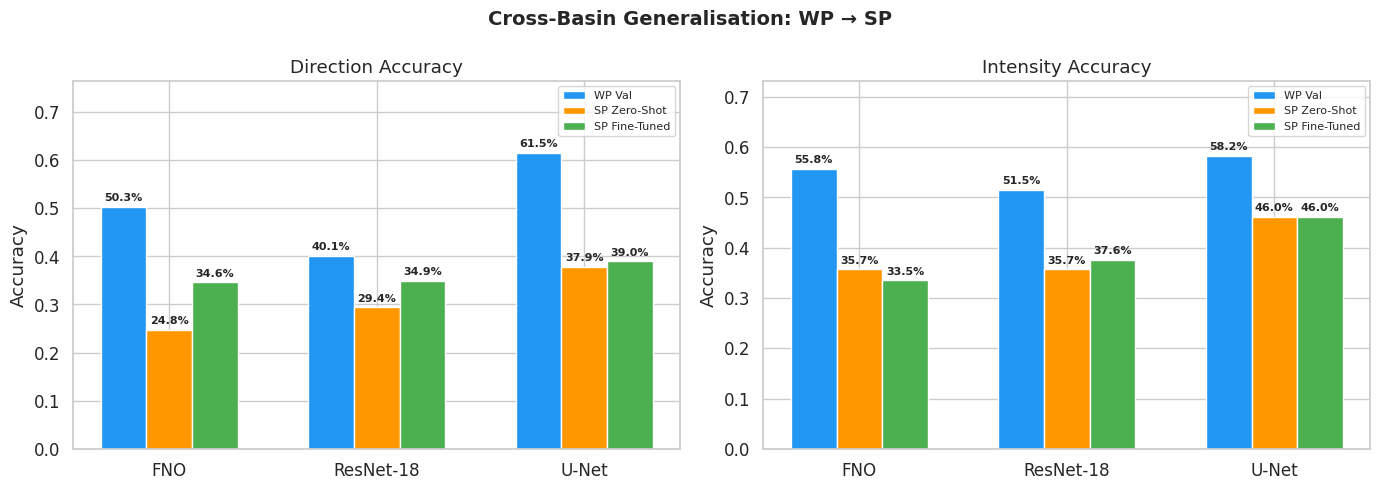

In [16]:
# ── Direction accuracy: grouped bar chart ──
settings = ["WP Val", "SP Zero-Shot", "SP Fine-Tuned"]
colours  = ["#2196F3", "#FF9800", "#4CAF50"]
x = np.arange(len(MODEL_NAMES))
w = 0.22

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for ax, metric, title in zip(
        axes, ["dir_acc", "int_acc"], ["Direction Accuracy", "Intensity Accuracy"]):
    for i, (setting, col) in enumerate(zip(settings, colours)):
        vals = [results[name][setting][metric] for name in MODEL_NAMES]
        bars = ax.bar(x + i * w, vals, w, label=setting, color=col, edgecolor="white")
        for bar, v in zip(bars, vals):
            ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.008,
                    f"{v:.1%}", ha="center", va="bottom", fontsize=8, fontweight="bold")
    ax.set_xticks(x + w)
    ax.set_xticklabels(MODEL_NAMES)
    ax.set_ylabel("Accuracy")
    ax.set_title(title)
    ax.set_ylim(0, min(1.0, max(results[n][s][metric]
                                 for n in MODEL_NAMES for s in settings) + 0.15))
    ax.legend(fontsize=8)

fig.suptitle("Cross-Basin Generalisation: WP \u2192 SP", fontsize=14, fontweight="bold")
fig.tight_layout()
fig.savefig(FIG_DIR / "comparison_accuracy_bars.png", dpi=200, bbox_inches="tight")
plt.show()

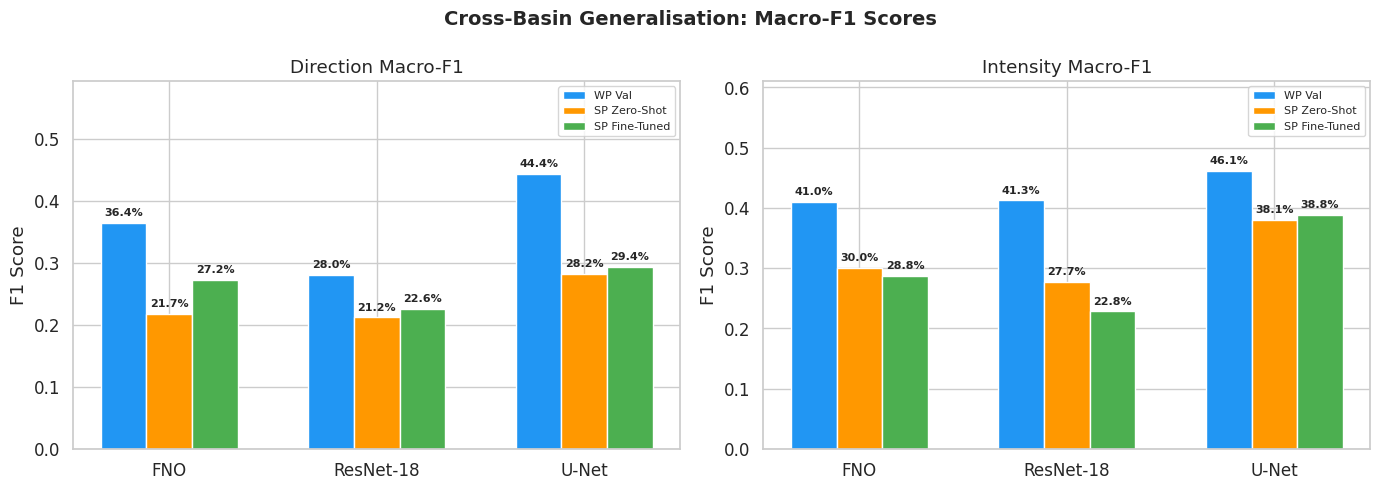

In [17]:
# ── Macro F1: grouped bar chart ──
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for ax, metric, title in zip(
        axes, ["dir_f1", "int_f1"], ["Direction Macro-F1", "Intensity Macro-F1"]):
    for i, (setting, col) in enumerate(zip(settings, colours)):
        vals = [results[name][setting][metric] for name in MODEL_NAMES]
        bars = ax.bar(x + i * w, vals, w, label=setting, color=col, edgecolor="white")
        for bar, v in zip(bars, vals):
            ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.008,
                    f"{v:.1%}", ha="center", va="bottom", fontsize=8, fontweight="bold")
    ax.set_xticks(x + w)
    ax.set_xticklabels(MODEL_NAMES)
    ax.set_ylabel("F1 Score")
    ax.set_title(title)
    ax.set_ylim(0, min(1.0, max(results[n][s][metric]
                                 for n in MODEL_NAMES for s in settings) + 0.15))
    ax.legend(fontsize=8)

fig.suptitle("Cross-Basin Generalisation: Macro-F1 Scores", fontsize=14, fontweight="bold")
fig.tight_layout()
fig.savefig(FIG_DIR / "comparison_f1_bars.png", dpi=200, bbox_inches="tight")
plt.show()

## 7. Confusion Matrices (SP Zero-Shot)

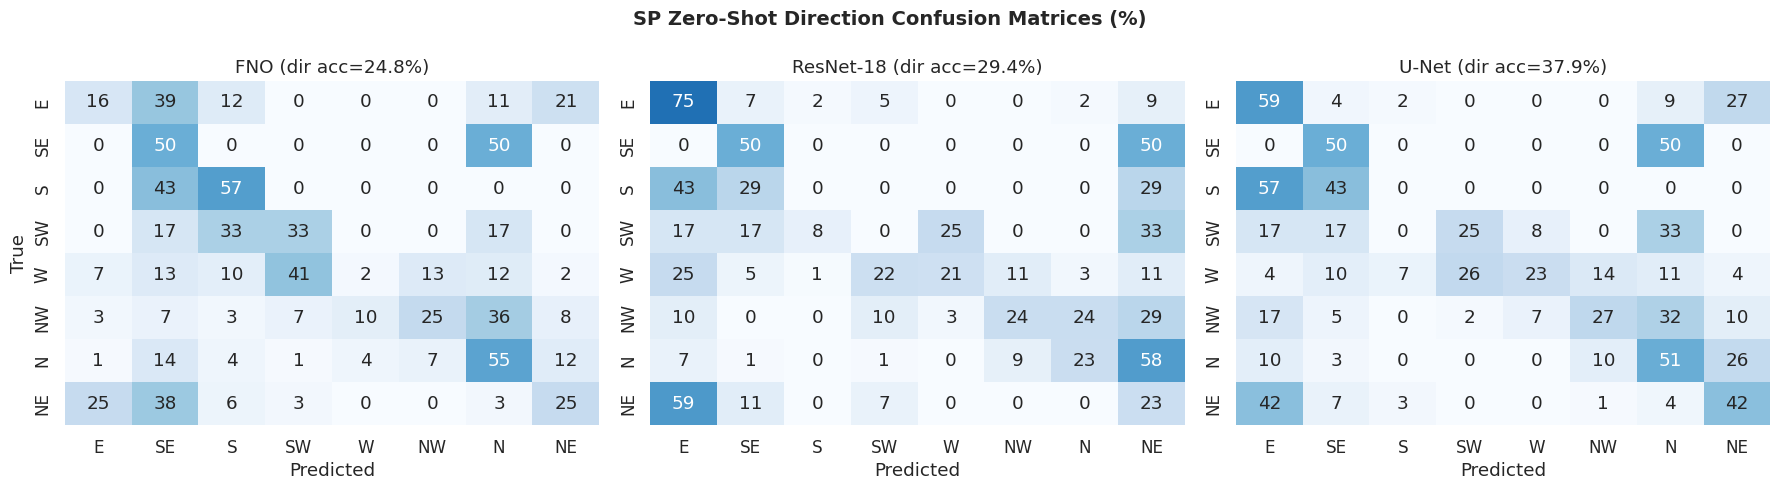

In [18]:
# ── Direction confusion matrices: zero-shot SP ──
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

for ax, name in zip(axes, MODEL_NAMES):
    m = results[name]["SP Zero-Shot"]
    cm = confusion_matrix(m["dir_trues"], m["dir_preds"], labels=range(N_DIR_CLASSES))
    cm_pct = cm / cm.sum(axis=1, keepdims=True) * 100
    sns.heatmap(cm_pct, annot=True, fmt=".0f", cmap="Blues",
                xticklabels=DIR_LABELS, yticklabels=DIR_LABELS,
                cbar=False, ax=ax, vmin=0, vmax=100)
    ax.set_title(f"{name} (dir acc={m['dir_acc']:.1%})")
    ax.set_xlabel("Predicted")
    ax.set_ylabel("True" if ax == axes[0] else "")

fig.suptitle("SP Zero-Shot Direction Confusion Matrices (%)", fontsize=14, fontweight="bold")
fig.tight_layout()
fig.savefig(FIG_DIR / "comparison_cm_dir_zeroshot.png", dpi=200, bbox_inches="tight")
plt.show()

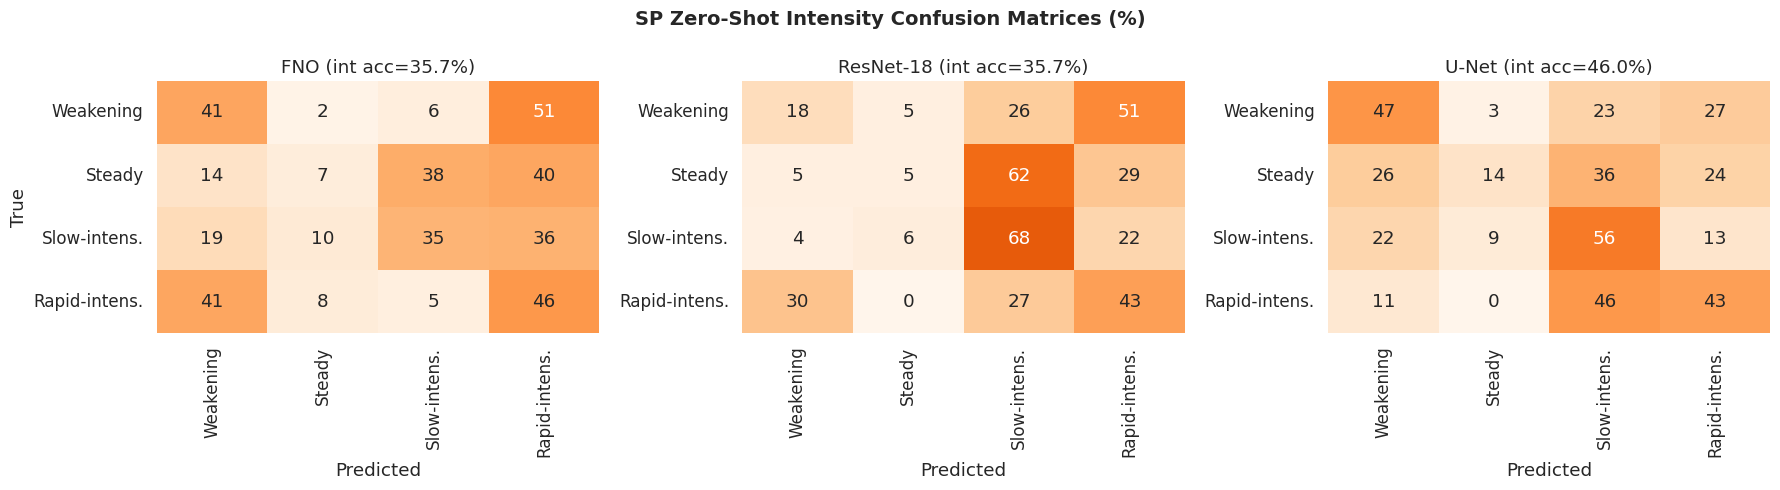

In [19]:
# ── Intensity confusion matrices: zero-shot SP ──
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

for ax, name in zip(axes, MODEL_NAMES):
    m = results[name]["SP Zero-Shot"]
    cm = confusion_matrix(m["int_trues"], m["int_preds"], labels=range(N_INT_CLASSES))
    cm_pct = cm / cm.sum(axis=1, keepdims=True) * 100
    sns.heatmap(cm_pct, annot=True, fmt=".0f", cmap="Oranges",
                xticklabels=INTE_LABELS, yticklabels=INTE_LABELS,
                cbar=False, ax=ax, vmin=0, vmax=100)
    ax.set_title(f"{name} (int acc={m['int_acc']:.1%})")
    ax.set_xlabel("Predicted")
    ax.set_ylabel("True" if ax == axes[0] else "")

fig.suptitle("SP Zero-Shot Intensity Confusion Matrices (%)", fontsize=14, fontweight="bold")
fig.tight_layout()
fig.savefig(FIG_DIR / "comparison_cm_int_zeroshot.png", dpi=200, bbox_inches="tight")
plt.show()

## 8. Fine-Tuning Impact

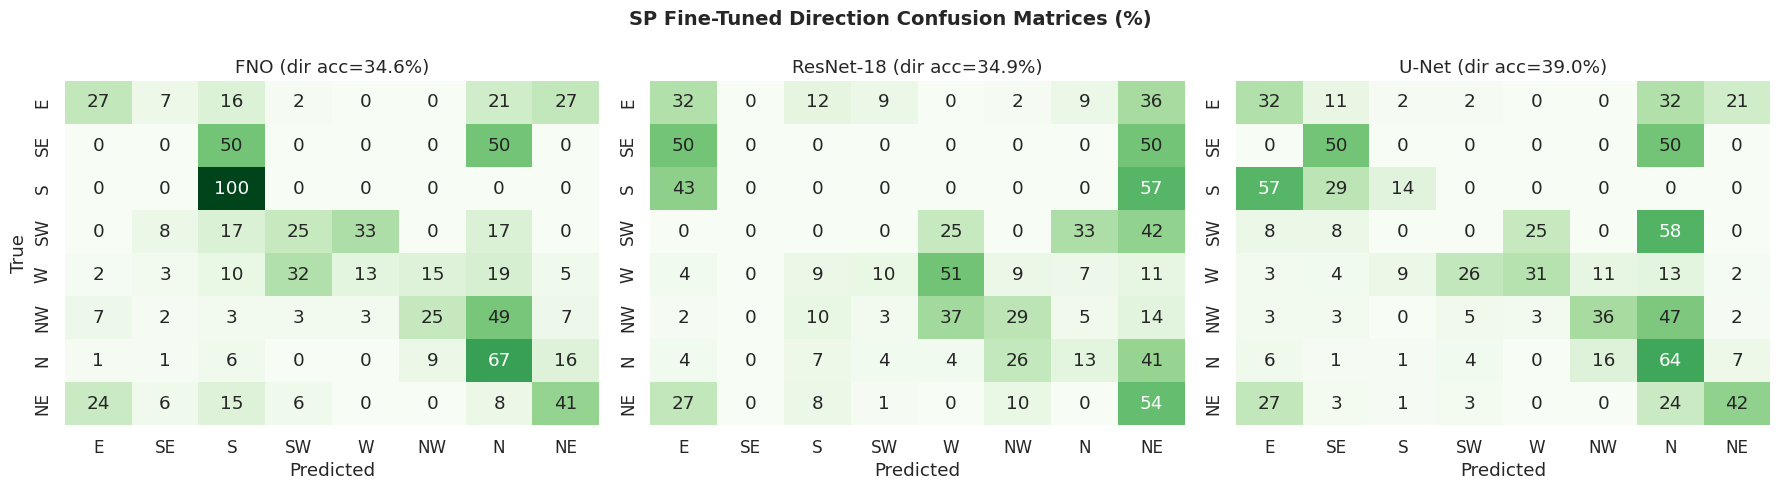

In [20]:
# ── Direction confusion matrices: fine-tuned SP ──
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

for ax, name in zip(axes, MODEL_NAMES):
    m = results[name]["SP Fine-Tuned"]
    cm = confusion_matrix(m["dir_trues"], m["dir_preds"], labels=range(N_DIR_CLASSES))
    cm_pct = cm / cm.sum(axis=1, keepdims=True) * 100
    sns.heatmap(cm_pct, annot=True, fmt=".0f", cmap="Greens",
                xticklabels=DIR_LABELS, yticklabels=DIR_LABELS,
                cbar=False, ax=ax, vmin=0, vmax=100)
    ax.set_title(f"{name} (dir acc={m['dir_acc']:.1%})")
    ax.set_xlabel("Predicted")
    ax.set_ylabel("True" if ax == axes[0] else "")

fig.suptitle("SP Fine-Tuned Direction Confusion Matrices (%)", fontsize=14, fontweight="bold")
fig.tight_layout()
fig.savefig(FIG_DIR / "comparison_cm_dir_finetuned.png", dpi=200, bbox_inches="tight")
plt.show()

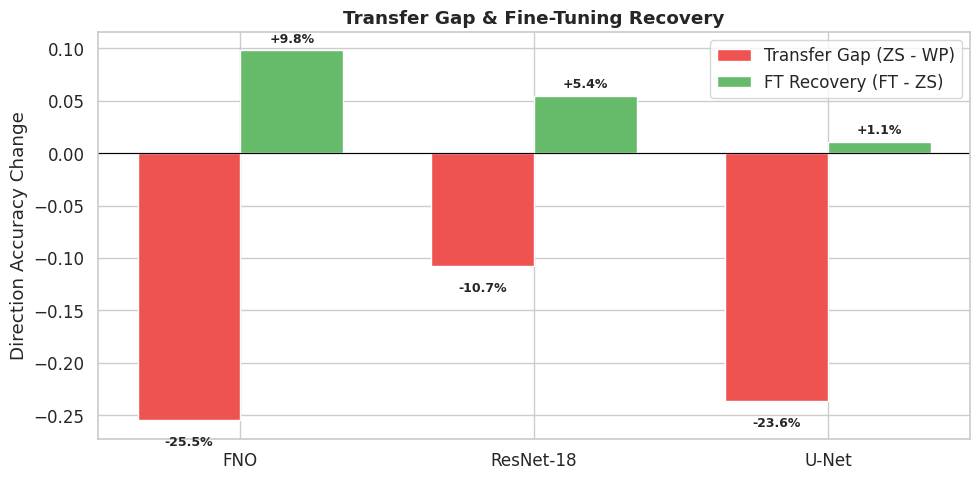

In [21]:
# ── Transfer gap waterfall chart ──
fig, ax = plt.subplots(figsize=(10, 5))

x = np.arange(len(MODEL_NAMES))
w = 0.35

gaps = [results[n]["SP Zero-Shot"]["dir_acc"] - results[n]["WP Val"]["dir_acc"]
        for n in MODEL_NAMES]
recoveries = [results[n]["SP Fine-Tuned"]["dir_acc"] - results[n]["SP Zero-Shot"]["dir_acc"]
              for n in MODEL_NAMES]

bars1 = ax.bar(x - w/2, gaps, w, label="Transfer Gap (ZS - WP)",
               color="#EF5350", edgecolor="white")
bars2 = ax.bar(x + w/2, recoveries, w, label="FT Recovery (FT - ZS)",
               color="#66BB6A", edgecolor="white")

for bars in [bars1, bars2]:
    for bar in bars:
        h = bar.get_height()
        ax.text(bar.get_x() + bar.get_width()/2, h + (0.005 if h >= 0 else -0.015),
                f"{h:+.1%}", ha="center", va="bottom" if h >= 0 else "top",
                fontsize=9, fontweight="bold")

ax.axhline(0, color="black", linewidth=0.8)
ax.set_xticks(x)
ax.set_xticklabels(MODEL_NAMES)
ax.set_ylabel("Direction Accuracy Change")
ax.set_title("Transfer Gap & Fine-Tuning Recovery", fontweight="bold")
ax.legend()
fig.tight_layout()
fig.savefig(FIG_DIR / "comparison_transfer_gap.png", dpi=200, bbox_inches="tight")
plt.show()

## 9. Per-Class F1 Comparison

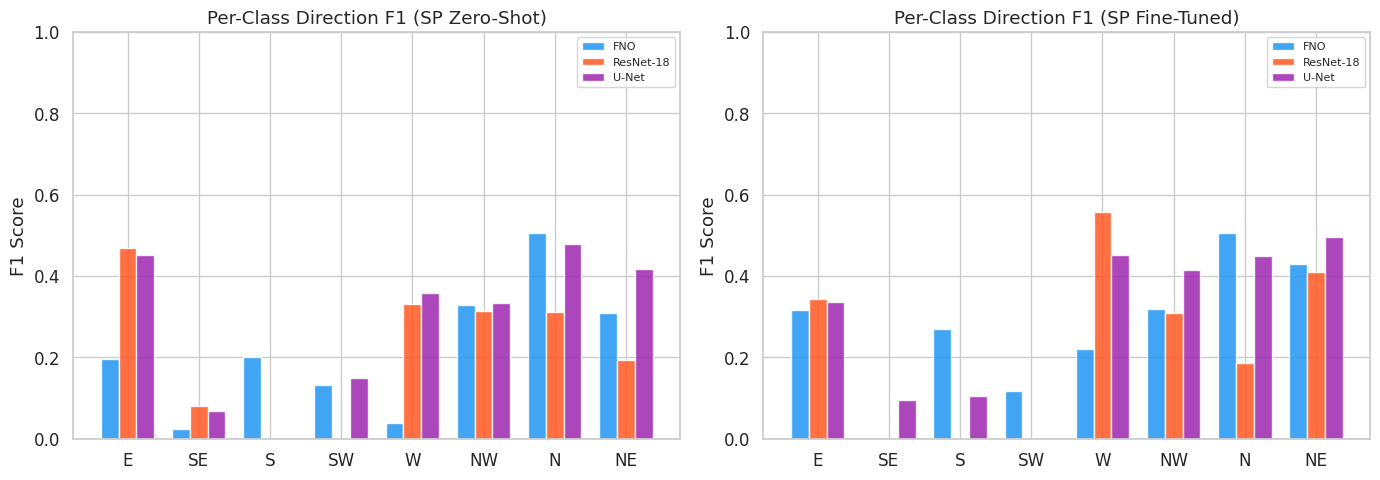

In [22]:
from sklearn.metrics import f1_score as f1_fn

# ── Per-class direction F1 on SP zero-shot ──
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
model_colours = ["#2196F3", "#FF5722", "#9C27B0"]

for ax, setting, title in zip(axes, ["SP Zero-Shot", "SP Fine-Tuned"],
                               ["SP Zero-Shot", "SP Fine-Tuned"]):
    x_cls = np.arange(N_DIR_CLASSES)
    w_cls = 0.25
    for i, (name, col) in enumerate(zip(MODEL_NAMES, model_colours)):
        m = results[name][setting]
        per_f1 = f1_fn(m["dir_trues"], m["dir_preds"],
                        labels=range(N_DIR_CLASSES), average=None, zero_division=0)
        ax.bar(x_cls + i * w_cls, per_f1, w_cls, label=name, color=col,
               edgecolor="white", alpha=0.85)
    ax.set_xticks(x_cls + w_cls)
    ax.set_xticklabels(DIR_LABELS)
    ax.set_ylabel("F1 Score")
    ax.set_title(f"Per-Class Direction F1 ({title})")
    ax.set_ylim(0, 1.0)
    ax.legend(fontsize=8)

fig.tight_layout()
fig.savefig(FIG_DIR / "comparison_perclass_f1.png", dpi=200, bbox_inches="tight")
plt.show()

## 10. Radar Chart: Multi-Metric Comparison

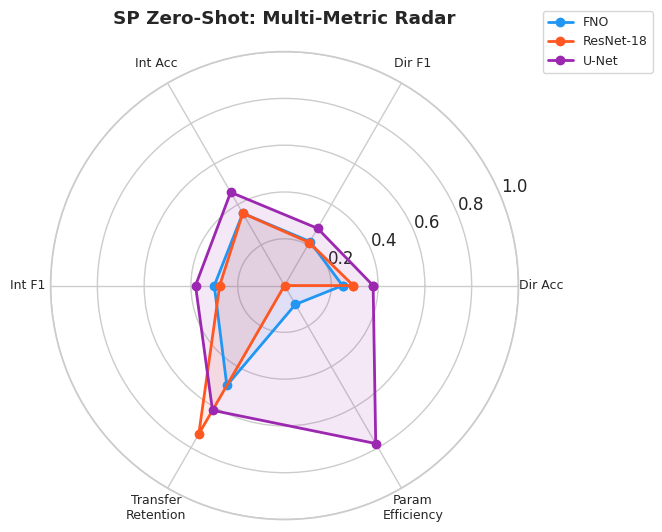

In [23]:
# ── Radar chart: 6 metrics per model (SP zero-shot) ──
metrics_radar = ["dir_acc", "dir_f1", "int_acc", "int_f1"]
metric_labels = ["Dir Acc", "Dir F1", "Int Acc", "Int F1"]

# Add transfer gap (normalised) and param efficiency
param_counts = {
    "FNO": sum(p.numel() for p in fno_wp.parameters()),
    "ResNet-18": sum(p.numel() for p in resnet_wp.parameters()),
    "U-Net": sum(p.numel() for p in unet_wp.parameters()),
}
max_params = max(param_counts.values())

angles = np.linspace(0, 2 * np.pi, len(metric_labels) + 2, endpoint=False).tolist()
all_labels = metric_labels + ["Transfer\nRetention", "Param\nEfficiency"]
angles_closed = angles + [angles[0]]

fig, ax = plt.subplots(figsize=(7, 7), subplot_kw=dict(polar=True))

for name, col in zip(MODEL_NAMES, model_colours):
    vals = [results[name]["SP Zero-Shot"][m] for m in metrics_radar]
    # Transfer retention = SP_ZS / WP_val (closer to 1 = better transfer)
    wp_dir = results[name]["WP Val"]["dir_acc"]
    sp_dir = results[name]["SP Zero-Shot"]["dir_acc"]
    transfer_retention = sp_dir / wp_dir if wp_dir > 0 else 0
    vals.append(transfer_retention)
    # Param efficiency = 1 - (params / max_params)
    vals.append(1 - param_counts[name] / max_params)
    vals_closed = vals + [vals[0]]
    ax.plot(angles_closed, vals_closed, "o-", label=name, color=col, linewidth=2)
    ax.fill(angles_closed, vals_closed, alpha=0.1, color=col)

ax.set_xticks(angles)
ax.set_xticklabels(all_labels, fontsize=9)
ax.set_ylim(0, 1)
ax.set_title("SP Zero-Shot: Multi-Metric Radar", fontweight="bold", pad=20)
ax.legend(loc="upper right", bbox_to_anchor=(1.3, 1.1), fontsize=9)
fig.tight_layout()
fig.savefig(FIG_DIR / "comparison_radar.png", dpi=200, bbox_inches="tight")
plt.show()

## 11. Classification Reports

In [24]:
# ── Detailed classification reports (SP zero-shot) ──
for name in MODEL_NAMES:
    m = results[name]["SP Zero-Shot"]
    print(f"\n{'='*60}")
    print(f" {name} — SP Zero-Shot Direction")
    print(f"{'='*60}")
    print(classification_report(
        m["dir_trues"], m["dir_preds"],
        target_names=DIR_LABELS, zero_division=0))

    print(f" {name} — SP Zero-Shot Intensity")
    print(f"{'-'*60}")
    print(classification_report(
        m["int_trues"], m["int_preds"],
        target_names=INTE_LABELS, zero_division=0))


 FNO — SP Zero-Shot Direction
              precision    recall  f1-score   support

           E       0.25      0.16      0.20        56
          SE       0.01      0.50      0.02         2
           S       0.12      0.57      0.20         7
          SW       0.08      0.33      0.13        12
           W       0.18      0.02      0.04        91
          NW       0.47      0.25      0.33        59
           N       0.47      0.55      0.51        69
          NE       0.40      0.25      0.31        71

    accuracy                           0.25       367
   macro avg       0.25      0.33      0.22       367
weighted avg       0.33      0.25      0.26       367

 FNO — SP Zero-Shot Intensity
------------------------------------------------------------
               precision    recall  f1-score   support

    Weakening       0.60      0.41      0.49       164
       Steady       0.14      0.07      0.10        42
 Slow-intens.       0.61      0.35      0.45       124
Rapid-

## 12. Summary & Key Findings

In [25]:
# ── Final summary table ──
print("\n" + "=" * 80)
print(" FINAL COMPARISON SUMMARY")
print("=" * 80)
print(f"{'Model':12s} | {'Params':>10s} | {'WP Dir':>7s} | {'SP-ZS Dir':>9s} | "
      f"{'Gap':>6s} | {'SP-FT Dir':>9s} | {'Recovery':>8s}")
print("-" * 80)

for name in MODEL_NAMES:
    wp  = results[name]["WP Val"]["dir_acc"]
    zs  = results[name]["SP Zero-Shot"]["dir_acc"]
    ft  = results[name]["SP Fine-Tuned"]["dir_acc"]
    n_p = f"{param_counts[name]:,d}"
    print(f"{name:12s} | {n_p:>10s} | {wp:>6.1%} | {zs:>8.1%} | "
          f"{zs-wp:>+5.1%} | {ft:>8.1%} | {ft-zs:>+7.1%}")

print("=" * 80)

# ── Identify best model ──
best_zs = max(MODEL_NAMES, key=lambda n: results[n]["SP Zero-Shot"]["dir_acc"])
best_ft = max(MODEL_NAMES, key=lambda n: results[n]["SP Fine-Tuned"]["dir_acc"])
best_eff = min(MODEL_NAMES, key=lambda n: (
    -results[n]["SP Zero-Shot"]["dir_acc"] / (param_counts[n] / 1e6)))

print(f"\nBest zero-shot transfer:  {best_zs}")
print(f"Best after fine-tuning:   {best_ft}")
print(f"Best param efficiency:    {best_eff} "
      f"({results[best_eff]['SP Zero-Shot']['dir_acc']:.1%} with "
      f"{param_counts[best_eff]/1e6:.1f}M params)")


 FINAL COMPARISON SUMMARY
Model        |     Params |  WP Dir | SP-ZS Dir |    Gap | SP-FT Dir | Recovery
--------------------------------------------------------------------------------
FNO          | 10,281,596 |  50.3% |    24.8% | -25.5% |    34.6% |   +9.8%
ResNet-18    | 11,335,628 |  40.1% |    29.4% | -10.7% |    34.9% |   +5.4%
U-Net        |  2,496,312 |  61.5% |    37.9% | -23.6% |    39.0% |   +1.1%

Best zero-shot transfer:  U-Net
Best after fine-tuning:   U-Net
Best param efficiency:    U-Net (37.9% with 2.5M params)


In [ ]:
# ── Save all figures list ──
print("\nFigures saved:")
for f in sorted(FIG_DIR.glob("comparison_*.png")):
    print(f"  {f.name}")


Figures saved:
  comparison_accuracy_bars.png
  comparison_cm_dir_finetuned.png
  comparison_cm_dir_zeroshot.png
  comparison_cm_int_zeroshot.png
  comparison_f1_bars.png
  comparison_perclass_f1.png
  comparison_radar.png
  comparison_transfer_gap.png


: 